In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

In [4]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 529.7 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.6 MB 529.7 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.6 MB 529.7 kB/s eta 0:00:03
   ------------ ------

## Dataset Loading & Preprocessing

[*********************100%***********************]  1 of 1 completed


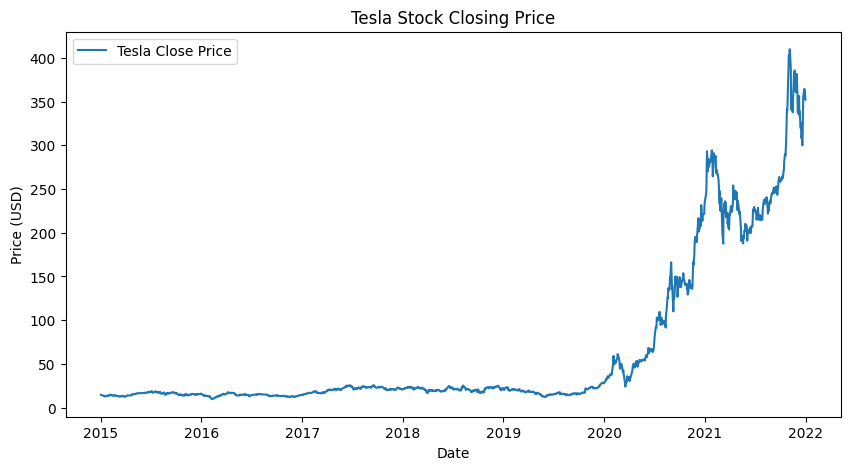

In [ ]:
data = yf.download("TSLA", start="2015-01-01", end="2022-01-01")

close_prices = data[['Close']]

plt.figure(figsize=(10,5))
plt.plot(close_prices, label="Tesla Close Price")
plt.title("Tesla Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [6]:
print(close_prices.isnull().sum())

close_prices.fillna(method='ffill', inplace=True)

Price  Ticker
Close  TSLA      0
dtype: int64


C:\Users\aksha\AppData\Local\Temp\ipykernel_26476\2570395651.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close_prices.fillna(method='ffill', inplace=True)
C:\Users\aksha\AppData\Local\Temp\ipykernel_26476\2570395651.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_prices.fillna(method='ffill', inplace=True)


In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices.values)

In [8]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, window_size=60)

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [9]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Model Training & Validation

In [10]:
model = Sequential([
    GRU(50, return_sequences=True, input_shape=(60,1)),
    GRU(50),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

c:\Users\aksha\anaconda3\envs\deep_learning\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,              
    restore_best_weights=True
)

In [15]:
history = model.fit(
    X_train, y_train,
    epochs=30,                
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.6130e-06 - val_loss: 9.4664e-05
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.0852e-06 - val_loss: 9.5120e-05
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.1009e-06 - val_loss: 1.2494e-04
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.9745e-06 - val_loss: 2.0234e-04
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.6485e-06 - val_loss: 1.0413e-04
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.1735e-06 - val_loss: 8.8836e-05
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.4202e-06 - val_loss: 8.9669e-05
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.4114e-06 - val_loss: 8.5111e-05
Epoch 9/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.2308e-06 - val_loss: 8.5585e-05
Epoch 10/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.8307e-06 - val_loss: 1.2236e-04
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.5227e-06 - val_los

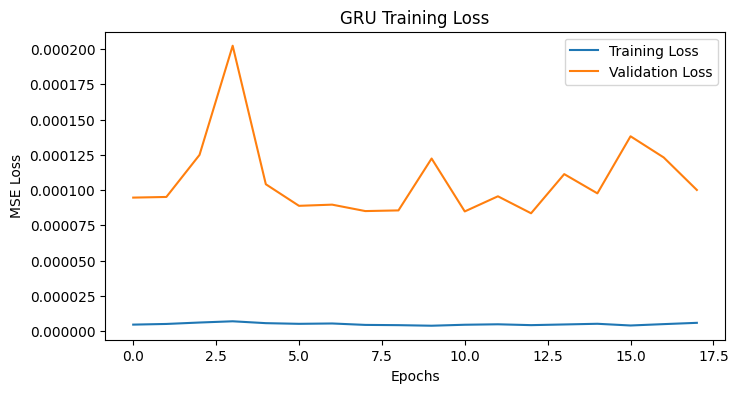

In [16]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("GRU Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [17]:
predicted_scaled = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [18]:
predicted_prices = scaler.inverse_transform(predicted_scaled.reshape(-1,1))
actual_prices = scaler.inverse_transform(y_test.reshape(-1,1))

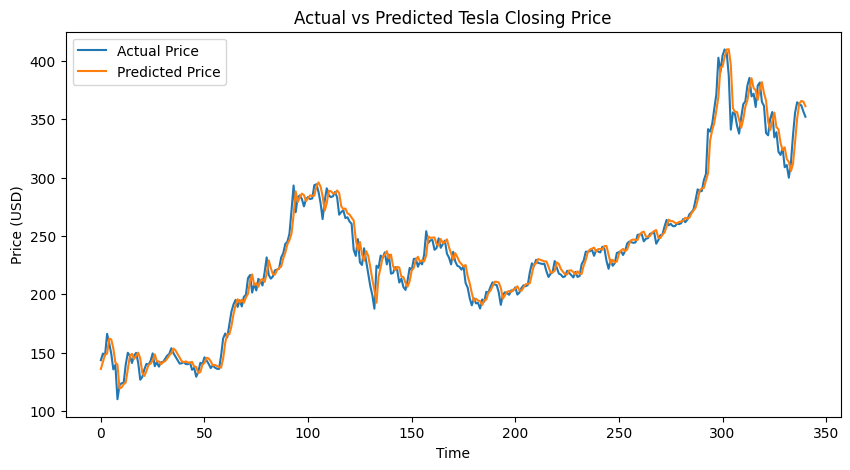

In [19]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices, label="Actual Price")
plt.plot(predicted_prices, label="Predicted Price")
plt.title("Actual vs Predicted Tesla Closing Price")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [20]:
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")

RMSE: 9.44
MAE : 6.68


## Extension tasks

## RNN

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(60, 1)),
    SimpleRNN(50),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/25


c:\Users\aksha\anaconda3\envs\deep_learning\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0045 - val_loss: 0.0057
Epoch 2/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0775e-04 - val_loss: 0.0055
Epoch 3/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.6634e-05 - val_loss: 0.0027
Epoch 4/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.6666e-05 - val_loss: 0.0016
Epoch 5/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.7522e-05 - val_loss: 0.0011
Epoch 6/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3017e-05 - val_loss: 8.7069e-04
Epoch 7/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.0338e-05 - val_loss: 7.6071e-04
Epoch 8/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7934e-05 - val_loss: 6.8034e-04
Epoch 9/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7306e-05 - val_loss: 6.4801e-04
Epoch 10/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.4755e-05 - val_loss: 5.6678e-04
Epoch 11/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4274e-05 - val_loss: 4.9602e-04
Epoch 12/25
39/39 ━━

In [26]:
rnn_pred = rnn_model.predict(X_test)

rnn_pred = scaler.inverse_transform(rnn_pred)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

rnn_rmse = np.sqrt(mean_squared_error(actual, rnn_pred))
rnn_mae  = mean_absolute_error(actual, rnn_pred)

print("RNN RMSE:", rnn_rmse)
print("RNN MAE :", rnn_mae)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
RNN RMSE: 39.276305672747505
RNN MAE : 32.96037050845686


In [39]:
results = []

results.append({
    "Model": "Vanilla RNN",
    "RMSE": round(rnn_rmse, 2),
    "MAE": round(rnn_mae, 2)
})

results.append({
    "Model": "GRU",
    "RMSE": round(rmse, 2),
    "MAE": round(mae, 2)
})

In [41]:
results_df = pd.DataFrame(results)
print("\nModel Comparison")
print(results_df.to_string(index=False))


Model Comparison
      Model  RMSE   MAE
Vanilla RNN 39.28 32.96
        GRU  9.44  6.68


## Dropout

In [27]:
from tensorflow.keras.layers import Dropout

gru_dropout_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(60,1)),
    Dropout(0.2),
    GRU(50),
    Dropout(0.2),
    Dense(1)
])

gru_dropout_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

gru_dropout_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30


c:\Users\aksha\anaconda3\envs\deep_learning\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 1.4001e-04 - val_loss: 8.1965e-04
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.7877e-05 - val_loss: 2.2942e-04
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.1349e-05 - val_loss: 2.3455e-04
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.2521e-05 - val_loss: 2.2201e-04
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.3364e-05 - val_loss: 2.1066e-04


In [42]:
dropout_pred = gru_dropout_model.predict(X_test)
dropout_pred = scaler.inverse_transform(dropout_pred)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [43]:
dropout_rmse = np.sqrt(mean_squared_error(actual, dropout_pred))
dropout_mae  = mean_absolute_error(actual, dropout_pred)

In [44]:
results.append({
    "Model": "GRU + Dropout",
    "RMSE": round(dropout_rmse, 2),
    "MAE": round(dropout_mae, 2)
})

results_df = pd.DataFrame(results)
print("\nEffect of Dropout")
print(results_df.to_string(index=False))


Effect of Dropout
        Model  RMSE   MAE
  Vanilla RNN 39.28 32.96
          GRU  9.44  6.68
GRU + Dropout 38.04 33.67


## MultiStep GRU

In [28]:
def create_multistep_sequences(data, window=60, horizon=5):
    X, y = [], []
    for i in range(window, len(data) - horizon):
        X.append(data[i-window:i, 0])
        y.append(data[i:i+horizon, 0])
    return np.array(X), np.array(y)

X_multi, y_multi = create_multistep_sequences(scaled_data)

X_multi = X_multi.reshape(X_multi.shape[0], X_multi.shape[1], 1)

In [29]:
split = int(0.8 * len(X_multi))
X_train_m, X_test_m = X_multi[:split], X_multi[split:]
y_train_m, y_test_m = y_multi[:split], y_multi[split:]

In [30]:
multi_step_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(60,1)),
    GRU(50),
    Dense(5)   # next 5 days
])

multi_step_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

multi_step_model.fit(
    X_train_m, y_train_m,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.3938e-04 - val_loss: 0.0055
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.2415e-05 - val_loss: 4.6797e-04
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.4016e-05 - val_loss: 4.4820e-04
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.4845e-05 - val_loss: 4.3683e-04
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.7340e-05 - val_loss: 5.8215e-04
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.4322e-05 - val_loss: 5.0183e-04
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.2985e-05 - val_loss: 4.3295e-04
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.3440e-05 - val_loss: 4.1045e-04
Epoch 9/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.5671e-05 - val_loss: 4.9433e-04
Epoch 10/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.2456e-05 - val_loss: 4.8236e-04
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.2251e-05 - 

In [45]:
sample_pred = multi_step_model.predict(X_test_m[:1])
sample_pred = scaler.inverse_transform(sample_pred.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


In [46]:
print("\nNext 5-Day Forecast (Sample):")
for i, price in enumerate(sample_pred, start=1):
    print(f"Day {i}: ${price[0]:.2f}")


Next 5-Day Forecast (Sample):
Day 1: $132.21
Day 2: $129.37
Day 3: $133.85
Day 4: $133.13
Day 5: $132.26


## MultiVariate Input

In [31]:
features = data[['Open', 'High', 'Low', 'Close', 'Volume']]

scaler_multi = MinMaxScaler()
scaled_features = scaler_multi.fit_transform(features)

In [32]:
def create_multivariate_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])
        y.append(data[i, 3])  # Close price
    return np.array(X), np.array(y)

X_mv, y_mv = create_multivariate_sequences(scaled_features)

In [33]:
split = int(0.8 * len(X_mv))
X_train_mv, X_test_mv = X_mv[:split], X_mv[split:]
y_train_mv, y_test_mv = y_mv[:split], y_mv[split:]

In [34]:
multi_var_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(60, 5)),
    GRU(50),
    Dense(1)
])

multi_var_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

multi_var_model.fit(
    X_train_mv, y_train_mv,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30


c:\Users\aksha\anaconda3\envs\deep_learning\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.4828e-04 - val_loss: 0.0011
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.2645e-05 - val_loss: 2.5349e-04
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 9.4520e-06 - val_loss: 2.4879e-04
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.0356e-05 - val_loss: 2.7049e-04
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.4676e-06 - val_loss: 2.5648e-04
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.4071e-06 - val_loss: 2.3547e-04
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.0462e-06 - val_loss: 2.3148e-04
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.6287e-06 - val_loss: 2.5345e-04
Epoch 9/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.0191e-06 - val_loss: 2.1115e-04
Epoch 10/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 6.8466e-06 - val_loss: 2.4775e-04
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 7.1205e-06 - val_loss: 2

In [35]:
mv_pred = multi_var_model.predict(X_test_mv)
mv_pred = scaler.inverse_transform(mv_pred.reshape(-1,1))

actual_mv = scaler.inverse_transform(y_test_mv.reshape(-1,1))

mv_rmse = np.sqrt(mean_squared_error(actual_mv, mv_pred))
mv_mae  = mean_absolute_error(actual_mv, mv_pred)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [37]:
results = []
results.append({
    "Model": "Multivariate GRU (OHLCV)",
    "RMSE": round(mv_rmse, 2),
    "MAE": round(mv_mae, 2)
})

results_df = pd.DataFrame(results)
print("\nFinal Model Comparison")
print(results_df.to_string(index=False))


Final Model Comparison
                   Model  RMSE   MAE
Multivariate GRU (OHLCV) 13.19 10.43
